In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values

In [5]:
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

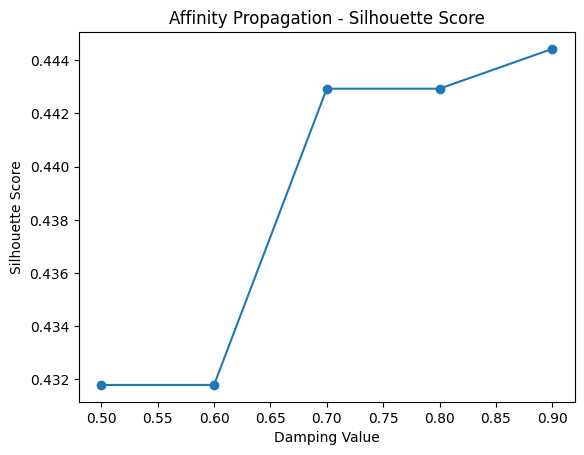

In [6]:
from sklearn.cluster import AffinityPropagation
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Affinity Propagation does not use n_clusters, so we tune 'damping'
damping_values = [0.5, 0.6, 0.7, 0.8, 0.9]

for d in damping_values:
    ap = AffinityPropagation(
        damping=d,
        max_iter=200,
        convergence_iter=15,
        random_state=0
    )
    
    labels = ap.fit_predict(x)
    
    # Check if more than 1 cluster exists
    if len(set(labels)) > 1:
        score = silhouette_score(x, labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

plt.plot(damping_values, silhouette_scores, marker='o')
plt.title("Affinity Propagation - Silhouette Score")
plt.xlabel("Damping Value")
plt.ylabel("Silhouette Score")
plt.show()

In [8]:
y_pred=ap.fit_predict(x)

In [9]:
y_pred

array([2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 3,
       2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 4, 3, 3, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 5, 7, 4, 6, 5, 7, 5, 7,
       4, 7, 5, 6, 5, 7, 5, 7, 5, 6, 4, 6, 5, 6, 4, 7, 5, 6, 5, 6, 5, 7,
       5, 6, 5, 7, 5, 7, 4, 6, 5, 6, 5, 7, 5, 6, 9, 7, 5, 7, 5, 6, 5, 6,
       5, 7, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8,
       9, 8])

In [10]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,y_pred)

In [11]:
score

0.4444241960201343

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


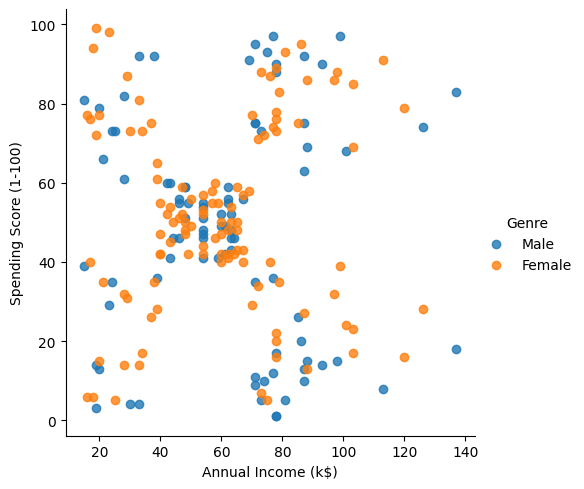

In [12]:
import seaborn as sns
facet = sns.lmplot(
    data = dataset,
       x = dataset.columns[3],
       y = dataset.columns[4],
     hue = dataset.columns[1],
  fit_reg= False,
  legend = True,
legend_out = True)